# TRISO coater — analytics

## Day 1 — terminal velocity of surrogate particles

Sweep particle diameter 200–1200 µm at three densities {2500, 6000, 10 800} kg/m³ across four gas conditions:

1. Air, 20 °C
2. Ar, 20 °C
3. Ar, 1400 °C
4. Ar/H₂ 50/50 mol, 1400 °C

Drag law: Schiller–Naumann with Newton cap at Re > 1000 (see `src/correlations.py`).
Gas properties are queried from Cantera (`gri30.yaml`) via `src/gasprops.py`.

In [1]:
import os, sys
REPO = os.path.abspath('.')
if REPO not in sys.path:
    sys.path.insert(0, REPO)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

from src.correlations import terminal_velocity
from src.gasprops import gas_props

with open('params/gases.yaml') as f:
    gases = yaml.safe_load(f)
with open('params/particles.yaml') as f:
    particles = yaml.safe_load(f)

P_Pa = gases['pressure_Pa']
sweep = particles['d_p_sweep_um']
d_p_um = np.arange(sweep['start'], sweep['stop'] + 1, sweep['step'])
d_p_m  = d_p_um * 1e-6
rho_p_list = particles['densities_kg_per_m3']

gas_table = {}
for name, spec in gases['cases'].items():
    rho, mu = gas_props(spec['T_K'], P_Pa, spec['composition'])
    gas_table[name] = {'label': spec['label'], 'T_K': spec['T_K'], 'rho': rho, 'mu': mu}

pd.DataFrame(gas_table).T[['label', 'T_K', 'rho', 'mu']]

,label,T_K,rho,mu
air_20C,"Air, 20 C",293.15,1.199356,0.000018
ar_20C,"Ar, 20 C",293.15,1.660769,0.000023
ar_1400C,"Ar, 1400 C",1673.15,0.290981,0.000078
ar_h2_1400C,"Ar/H2 50/50 mol, 1400 C",1673.15,0.152832,0.000072


In [2]:
rows = []
for gas_name, g in gas_table.items():
    for rho_p in rho_p_list:
        for d, dum in zip(d_p_m, d_p_um):
            u_t = terminal_velocity(float(d), float(rho_p), g['rho'], g['mu'])
            rows.append({'gas': gas_name, 'rho_p_kgm3': rho_p, 'd_p_um': int(dum), 'u_t_mps': u_t})

df = pd.DataFrame(rows)
table = df.pivot_table(index=['gas','rho_p_kgm3'], columns='d_p_um', values='u_t_mps')
table.round(3)

d_p_um                   200    250    300    350    400    450     500   \
gas         rho_p_kgm3                                                     
air_20C     2500        1.409  1.824  2.224  2.608  2.979  3.339   3.688   
            6000        2.636  3.337  4.006  4.647  5.264  5.862   6.442   
            10800       3.948  4.938  5.880  6.781  7.649  8.490   9.307   
ar_1400C    2500        0.641  0.960  1.316  1.701  2.105  2.521   2.946   
            6000        1.449  2.116  2.836  3.587  4.353  5.125   5.896   
            10800       2.461  3.524  4.640  5.778  6.921  8.058   9.183   
ar_20C      2500        1.168  1.517  1.853  2.176  2.489  2.792   3.086   
            6000        2.193  2.784  3.347  3.887  4.407  4.911   5.400   
            10800       3.292  4.127  4.920  5.679  6.411  7.120   7.808   
ar_h2_1400C 2500        0.708  1.070  1.483  1.937  2.422  2.929   3.453   
            6000        1.622  2.403  3.265  4.180  5.130  6.100   7.079   
            10800       2.789  4.061  5.427  6.846  8.291  9.743  11.193   

d_p_um                    550     600     650   ...    750     800     850   \
gas         rho_p_kgm3                          ...                           
air_20C     2500         4.029   4.361   4.686  ...   5.318   5.626   5.929   
            6000         7.008   7.561   8.102  ...   9.154   9.667  10.172   
            10800       10.104  10.882  11.644  ...  13.127  13.850  14.561   
ar_1400C    2500         3.375   3.806   4.237  ...   5.093   5.517   5.937   
            6000         6.664   7.424   8.177  ...   9.655  10.379  11.095   
            10800       10.292  11.386  12.463  ...  14.567  15.595  16.608   
ar_20C      2500         3.373   3.653   3.927  ...   4.460   4.719   4.974   
            6000         5.877   6.343   6.799  ...   7.685   8.117   8.542   
            10800        8.479   9.135   9.777  ...  11.026  11.634  12.234   
ar_h2_1400C 2500         3.987   4.529   5.074  ...   6.170   6.716   7.260   
            6000         8.061   9.040  10.015  ...  11.940  12.889  13.829   
            10800       12.632  14.057  15.465  ...  18.229  19.583  20.920   

d_p_um                    900     950     1000    1050    1100    1150    1200  
gas         rho_p_kgm3                                                          
air_20C     2500         6.227   6.522   6.812   7.099   7.382   7.663   7.940  
            6000        10.669  11.160  11.644  12.123  12.596  13.063  13.355  
            10800       15.263  15.955  16.358  16.761  17.156  17.541  17.919  
ar_1400C    2500         6.354   6.768   7.177   7.582   7.984   8.381   8.775  
            6000        11.802  12.500  13.189  13.871  14.544  15.210  15.869  
            10800       17.607  18.593  19.566  20.526  21.475  22.413  23.340  
ar_20C      2500         5.226   5.474   5.718   5.960   6.199   6.435   6.668  
            6000         8.961   9.374   9.782  10.185  10.583  10.977  11.367  
            10800       12.825  13.408  13.900  14.244  14.579  14.907  15.227  
ar_h2_1400C 2500         7.802   8.340   8.874   9.404   9.931  10.453  10.971  
            6000        14.758  15.677  16.586  17.485  18.375  19.255  20.127  
            10800       22.240  23.543  24.830  26.101  27.358  28.601  29.830  

[12 rows x 21 columns]

In [3]:
# Reference check — hand calc: 500 um, 6000 kg/m^3 in air at 20 C -> u_t ~ 6.44 m/s
ref = df[(df.gas=='air_20C') & (df.rho_p_kgm3==6000) & (df.d_p_um==500)]['u_t_mps'].iloc[0]
print(f'u_t(500 um, 6000 kg/m^3, air 20 C) = {ref:.3f} m/s  (hand calc: 6.44)')

u_t(500 um, 6000 kg/m^3, air 20 C) = 6.442 m/s  (hand calc: 6.44)


saved results/fig_d1_terminal_velocity.png


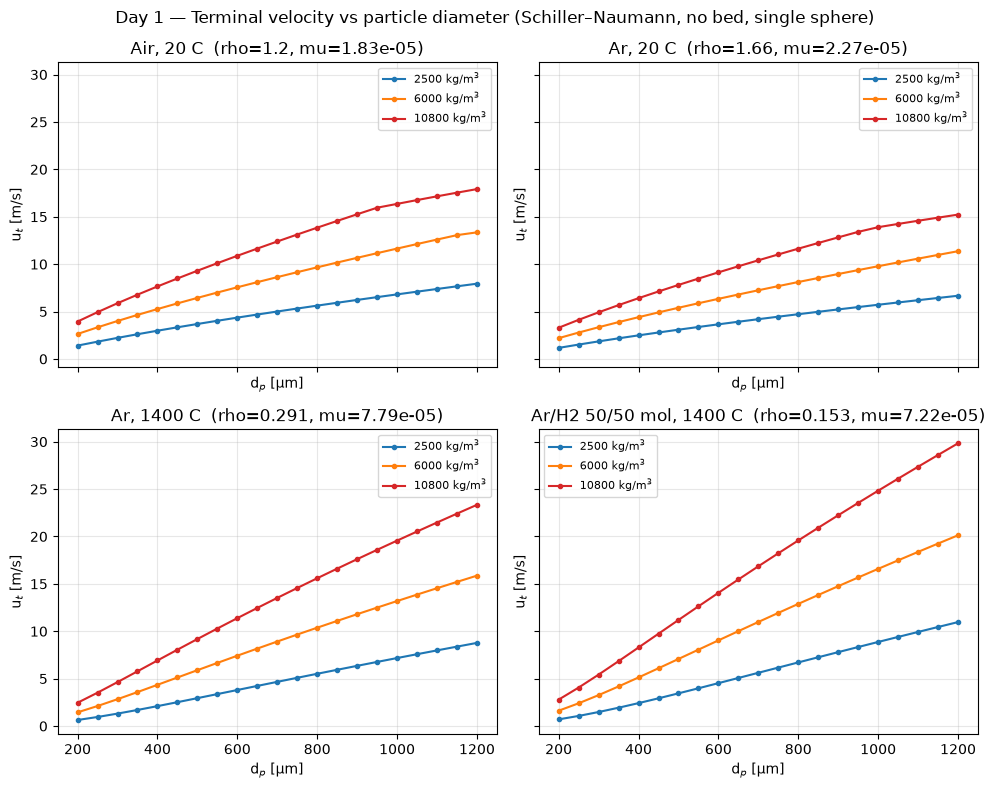

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
gas_names = list(gas_table.keys())
colors = {2500: 'tab:blue', 6000: 'tab:orange', 10800: 'tab:red'}

for ax, gas_name in zip(axes.flat, gas_names):
    g = gas_table[gas_name]
    for rho_p in rho_p_list:
        sub = df[(df.gas==gas_name) & (df.rho_p_kgm3==rho_p)]
        ax.plot(sub['d_p_um'], sub['u_t_mps'], marker='o', ms=3,
                color=colors[rho_p], label=f'{rho_p} kg/m$^3$')
    ax.set_title(f"{g['label']}  (rho={g['rho']:.3g}, mu={g['mu']:.2e})")
    ax.set_xlabel('d$_p$ [µm]')
    ax.set_ylabel('u$_t$ [m/s]')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

fig.suptitle('Day 1 — Terminal velocity vs particle diameter (Schiller–Naumann, no bed, single sphere)')
fig.tight_layout()
os.makedirs('results', exist_ok=True)
out = 'results/fig_d1_terminal_velocity.png'
fig.savefig(out, dpi=150)
print('saved', out)

## Day 2 — U_mf, U_ms and Geldart class for Case D

Add packed-bed and spouted-bed correlations and use them for the Missouri S&T 0.076 m
bed with Case D (ZrO₂/YSZ ~500 µm, 6000 kg/m³) surrogate particles in argon at
20 °C and at 1400 °C. Geometry from `params/geometry.yaml`; particle and sweep
parameters from `params/particles.yaml`.

Correlations (see `src/correlations.py`):

- Ergun (1952) packed-bed pressure drop
- Wen & Yu (1966) minimum fluidization velocity, via `archimedes`
- Geldart (1973) rule-based classifier
- Mathur & Gishler (1955) minimum spouting velocity


In [5]:
from src.correlations import geldart_class, umf_wen_yu, ums_mathur_gishler

with open('params/geometry.yaml') as f:
    geometry = yaml.safe_load(f)
D_c = geometry['bed_0p076m']['D_c_m']
D_i = geometry['bed_0p076m']['D_i_m']

caseD      = particles['case_D']
caseD_uo2  = particles['case_D_uo2']
d_p_D      = float(caseD['d_p_m'])
rho_p_D    = float(caseD['rho_p_kg_per_m3'])
rho_p_uo2  = float(caseD_uo2['rho_p_kg_per_m3'])

# Ar at 20 C is used for the Geldart chart placement — the gas density barely
# shifts the boundaries anyway (rho_p >> rho_g).
rho_ar20 = gas_table['ar_20C']['rho']

group_surrogate = geldart_class(d_p_D,     rho_p_D,   rho_ar20)
group_uo2       = geldart_class(d_p_D,     rho_p_uo2, rho_ar20)

print(f'Case D surrogate  (500 um, 6000 kg/m^3) -> Geldart group {group_surrogate}')
print(f'UO2 kernel        (500 um, 10800 kg/m^3) -> Geldart group {group_uo2}')
print()
print('Both particles sit clearly in Geldart Group D (spoutable): the coarse,'
      ' dense end of the chart where spouting rather than smooth fluidization is'
      ' the natural gas-solid contacting mode. This is what motivates using a'
      ' spouted bed in the first place.')


Case D surrogate  (500 um, 6000 kg/m^3) -> Geldart group D
UO2 kernel        (500 um, 10800 kg/m^3) -> Geldart group D

Both particles sit clearly in Geldart Group D (spoutable): the coarse, dense end of the chart where spouting rather than smooth fluidization is the natural gas-solid contacting mode. This is what motivates using a spouted bed in the first place.


In [6]:
H_spec = particles['H_sweep_m']
H_m = np.arange(H_spec['start'], H_spec['stop'] + 1e-12, H_spec['step'])

sweep_rows = []
for gas_name in ('ar_20C', 'ar_1400C'):
    g = gas_table[gas_name]
    u_mf = umf_wen_yu(d_p_D, rho_p_D, g['rho'], g['mu'])   # H-independent
    for H in H_m:
        u_ms = ums_mathur_gishler(d_p_D, rho_p_D, g['rho'], D_c, D_i, float(H))
        sweep_rows.append({
            'gas': gas_name, 'label': g['label'],
            'H_m': round(float(H), 4),
            'U_mf_mps': u_mf, 'U_ms_mps': u_ms,
            'U_ms_over_U_mf': u_ms / u_mf,
        })

df_d2 = pd.DataFrame(sweep_rows)
print('U_mf (Wen-Yu) at Ar 20 C   : {:.3f} m/s'.format(
    df_d2[df_d2.gas=='ar_20C']['U_mf_mps'].iloc[0]))
print('U_mf (Wen-Yu) at Ar 1400 C : {:.3f} m/s'.format(
    df_d2[df_d2.gas=='ar_1400C']['U_mf_mps'].iloc[0]))
df_d2.pivot_table(index='H_m', columns='label',
                  values=['U_ms_mps','U_ms_over_U_mf']).round(3)


U_mf (Wen-Yu) at Ar 20 C   : 0.332 m/s
U_mf (Wen-Yu) at Ar 1400 C : 0.114 m/s


U_ms_mps          U_ms_over_U_mf         
label Ar, 1400 C Ar, 20 C     Ar, 1400 C Ar, 20 C
H_m                                              
0.05       0.468    0.196          4.104    0.589
0.06       0.512    0.214          4.495    0.645
0.07       0.553    0.232          4.855    0.697
0.08       0.592    0.248          5.191    0.745
0.09       0.628    0.263          5.506    0.791
0.10       0.662    0.277          5.803    0.833
0.11       0.694    0.290          6.087    0.874
0.12       0.725    0.303          6.357    0.913
0.13       0.754    0.316          6.617    0.950
0.14       0.783    0.328          6.867    0.986
0.15       0.810    0.339          7.108    1.021
0.16       0.837    0.350          7.341    1.054
0.17       0.863    0.361          7.567    1.086
0.18       0.888    0.371          7.786    1.118
0.19       0.912    0.382          7.999    1.149
0.20       0.936    0.392          8.207    1.178

saved results/fig_d2_ums_vs_H.png


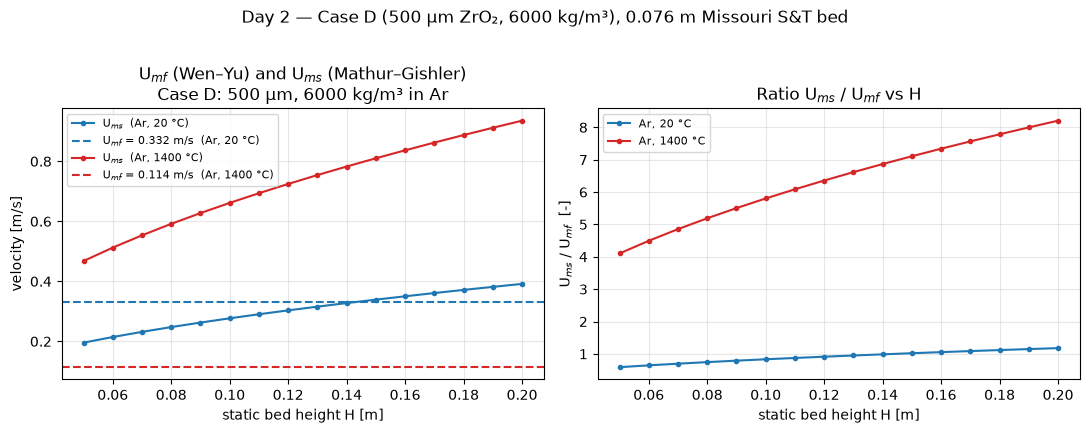

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

colors = {'ar_20C': 'tab:blue', 'ar_1400C': 'tab:red'}
labels = {'ar_20C': 'Ar, 20 °C', 'ar_1400C': 'Ar, 1400 °C'}

ax = axes[0]
for gas_name in ('ar_20C', 'ar_1400C'):
    sub = df_d2[df_d2.gas==gas_name].sort_values('H_m')
    u_mf = sub['U_mf_mps'].iloc[0]
    ax.plot(sub['H_m'], sub['U_ms_mps'], color=colors[gas_name],
            marker='o', ms=3, label=f'U$_{{ms}}$  ({labels[gas_name]})')
    ax.axhline(u_mf, color=colors[gas_name], linestyle='--',
               label=f'U$_{{mf}}$ = {u_mf:.3f} m/s  ({labels[gas_name]})')
ax.set_xlabel('static bed height H [m]')
ax.set_ylabel('velocity [m/s]')
ax.set_title('U$_{mf}$ (Wen–Yu) and U$_{ms}$ (Mathur–Gishler)\nCase D: 500 µm, 6000 kg/m³ in Ar')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

ax = axes[1]
for gas_name in ('ar_20C', 'ar_1400C'):
    sub = df_d2[df_d2.gas==gas_name].sort_values('H_m')
    ax.plot(sub['H_m'], sub['U_ms_over_U_mf'], color=colors[gas_name],
            marker='o', ms=3, label=labels[gas_name])
ax.set_xlabel('static bed height H [m]')
ax.set_ylabel('U$_{ms}$ / U$_{mf}$  [-]')
ax.set_title('Ratio U$_{ms}$ / U$_{mf}$ vs H')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

fig.suptitle('Day 2 — Case D (500 µm ZrO₂, 6000 kg/m³), 0.076 m Missouri S&T bed', y=1.02)
fig.tight_layout()
out = 'results/fig_d2_ums_vs_H.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
print('saved', out)


## Day 4 — Model-choice particle counts

For the 0.076 m Missouri S&T bed (cone + cylinder, see `params/geometry.yaml`)
loaded with Case D surrogate (500 µm, 6000 kg/m³) at a static bed height
H = 0.10 m and solids volume fraction ε_s ≈ 0.6, estimate:

1. the number of particles in the **full 3D bed**, and
2. the number of particles in a **pseudo-2D slab** of thickness t ≈ 5·d_p
   taken through the bed axis.

These counts feed `notes/day04_model_choice.md` (TFM vs DEM vs CGP-DEM vs PIC
decision table) — they bound what a resolved-particle (DEM) run of this
geometry would cost, and show how much a pseudo-2D geometry collapses that cost.


In [8]:
import math, yaml

with open('params/geometry.yaml') as f:
    geo = yaml.safe_load(f)['bed_0p076m']
with open('params/particles.yaml') as f:
    pcl = yaml.safe_load(f)

D_c  = geo['D_c_m']
D_i  = geo['D_i_m']
cone_angle_deg = geo['cone_angle_deg']   # included cone angle

d_p  = float(pcl['case_D']['d_p_m'])
rho_p = float(pcl['case_D']['rho_p_kg_per_m3'])

est  = pcl['day4_count_estimate']
H_m             = float(est['H_static_m'])
eps_s           = float(est['eps_s'])
slab_particles  = int(est['slab_thickness_particles'])

# Cone frustum geometry.
#   half-angle of the cone wall relative to the vertical axis = cone_angle/2
#   h_cone is the axial height of the frustum from the orifice (D_i) up to D_c.
r_i = D_i / 2.0
r_c = D_c / 2.0
half_angle_rad = math.radians(cone_angle_deg / 2.0)
h_cone = (r_c - r_i) / math.tan(half_angle_rad)   # [m]

if H_m < h_cone:
    # Bed sits entirely inside the cone; truncate the frustum at r(H).
    r_top = r_i + H_m * math.tan(half_angle_rad)
    V_cone = (math.pi * H_m / 3.0) * (r_i**2 + r_i*r_top + r_top**2)
    V_cyl  = 0.0
    h_cyl  = 0.0
else:
    V_cone = (math.pi * h_cone / 3.0) * (r_i**2 + r_i*r_c + r_c**2)
    h_cyl  = H_m - h_cone
    V_cyl  = math.pi * r_c**2 * h_cyl

V_bed = V_cone + V_cyl                     # [m^3]
V_s   = eps_s * V_bed                      # solids volume [m^3]
V_p   = math.pi / 6.0 * d_p**3             # single-particle volume [m^3]
N_3D  = V_s / V_p                          # particle count in full 3D bed

# Pseudo-2D slab: thickness t = slab_particles * d_p, taken as a vertical slice
# through the bed axis. Its projected (in-plane) area is the vertical
# cross-section through the axis: a trapezoid for the cone + a rectangle for
# the cylinder.
t_slab = slab_particles * d_p
A_cone_proj = h_cone * (D_i + D_c) / 2.0   # trapezoid
A_cyl_proj  = h_cyl  * D_c                  # rectangle
A_proj = A_cone_proj + A_cyl_proj
V_slab = A_proj * t_slab
V_s_slab = eps_s * V_slab
N_2D = V_s_slab / V_p

print(f'Bed geometry (D_c={D_c*1e3:.1f} mm, D_i={D_i*1e3:.2f} mm, cone={cone_angle_deg} deg):')
print(f'  cone frustum height h_cone = {h_cone*1e3:.2f} mm')
print(f'  for H = {H_m*1e3:.1f} mm:  cone fills {min(H_m,h_cone)*1e3:.2f} mm, cylinder adds {h_cyl*1e3:.2f} mm')
print()
print(f'  V_cone  = {V_cone:.3e} m^3')
print(f'  V_cyl   = {V_cyl:.3e} m^3')
print(f'  V_bed   = {V_bed:.3e} m^3')
print(f'  V_s     = eps_s * V_bed = {V_s:.3e} m^3  (eps_s = {eps_s})')
print()
print(f'Particle (d_p={d_p*1e6:.0f} um, rho_p={rho_p:.0f} kg/m^3):')
print(f'  V_p     = {V_p:.3e} m^3')
print(f'  mass_p  = {rho_p*V_p:.3e} kg')
print()
print(f'Full 3D bed particle count:')
print(f'  N_3D    = V_s / V_p = {N_3D:.3e}  ~  {N_3D/1e6:.2f} million particles')
print()
print(f'Pseudo-2D slab (t = {slab_particles} d_p = {t_slab*1e3:.2f} mm):')
print(f'  A_proj  = {A_proj:.3e} m^2')
print(f'  V_slab  = {V_slab:.3e} m^3')
print(f'  N_slab  = {N_2D:.3e}  ~  {N_2D/1e3:.1f} thousand particles')
print()
print(f'Collapse factor (3D / slab): {V_bed/V_slab:.1f}x')


Bed geometry (D_c=76.0 mm, D_i=9.50 mm, cone=60 deg):
  cone frustum height h_cone = 57.59 mm
  for H = 100.0 mm:  cone fills 57.59 mm, cylinder adds 42.41 mm

  V_cone  = 9.933e-05 m^3
  V_cyl   = 1.924e-04 m^3
  V_bed   = 2.917e-04 m^3
  V_s     = eps_s * V_bed = 1.750e-04 m^3  (eps_s = 0.6)

Particle (d_p=500 um, rho_p=6000 kg/m^3):
  V_p     = 6.545e-11 m^3
  mass_p  = 3.927e-07 kg

Full 3D bed particle count:
  N_3D    = V_s / V_p = 2.674e+06  ~  2.67 million particles

Pseudo-2D slab (t = 5 d_p = 2.50 mm):
  A_proj  = 5.685e-03 m^2
  V_slab  = 1.421e-05 m^3
  N_slab  = 1.303e+05  ~  130.3 thousand particles

Collapse factor (3D / slab): 20.5x
